<a href="https://colab.research.google.com/github/AdrionRosanelli/LoRa_Sionna/blob/main/Lora_Phy_Tx_Block.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Teste de Implementação do Transmissor LoRa no Sionna PHY usando Block.**

Implementação realizada a usando a estrutura de block do Sionna:

    

# Implementação do transmissor da camada física do LoRa

*   Implementa geração de chirps
*   Modulação utilizando os chirps
*   Codifica dados em símbolos
*   Gera pacotes do LoRa

### Imports

Instalação e importação das bibliotecas. (Import do tutorial Part 1 Sionna PHY)

In [1]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(gpus)
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

import numpy as np

# For plotting
%matplotlib inline
# also try %matplotlib widget

import matplotlib.pyplot as plt

# for performance measurements
import time

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import sionna

from sionna.phy import Block
from sionna.phy.config import Config
from sionna.phy.utils import expand_to_rank
from sionna.phy.mapping import BinarySource
from sionna.phy.fec.crc import CRCEncoder

### Implementação da camada física do LoRa no bloco.

1. Inicialização

  *   Define parâmetros do LoRa.

2. Geração de chirps do LoRa:

  *   Chirp linear variando de 0 a BW.

3. Modulação usando chirp.

4. Calculo da frequência instantânea.

5. Geração de pacotes:

  *   Preâmbulo.
  *   Sincronismo.
  *   Cabeçalho.
  *   Payload.

6. Codificação dos bits

7. Analise do chirp




In [3]:

"""
LoRa PHY Transmitter — versão batch-paralela
=============================================
Estrutura inspirada no PUSCHTransmitter do Sionna:
  - Cada estágio do pipeline é uma operação aplicada a [batch_size, ...]

Pipeline:
    inputs [B, N_bits]
        │
        ▼
    whitening          → [B, N_bits]          (XOR vectorizado)
        │
        ▼
    generate_header    → [B, 20]              (operações matriciais por batch)
        │
        ▼
    concat + CRC       → [B, N_bits + 36]     (header 20b + payload + CRC 16b)
        │
        ▼
    hamming_encode     → [B, N_coded]         (padding uniforme no batch)
        │
        ▼
    interleaving       → [B, N_sym]           (operações 3-D / batch_dims)
        │
        ▼
    encode_data        → [B, N_sym, n_chips]  (produto externo batch)
        │
        ▼
    montagem pacote    → [B, total_samples]   (concat: preâmbulo + sync +
                                               down-chirps + dados)
"""

# import numpy as np
# import tensorflow as tf
# from sionna.phy import Block
# from sionna.phy.fec.crc import CRCEncoder


class LoRaPhyTransmitter(Block):
    """
    Transmissor LoRa com processamento batch-paralelo.

    Todos os estágios operam sobre [batch_size, ...] sem map_fn.
    Entradas de comprimento variável entre amostras do batch NÃO são suportadas:
    todas as amostras devem ter o mesmo num_bits (padrão Sionna/PUSCHTransmitter).
    """

    def __init__(self,
                 spreading_factor=7,
                 bandwidth=125e3,
                 coding_rate=1,
                 num_preamble=8,
                 sync_word=0x34,
                 crc_on=True,
                 carrier_freq=None,
                 debug=False,
                 precision=None,
                 **kwargs):

        super().__init__(precision=precision, **kwargs)

        self.sf = spreading_factor
        self.bw = tf.constant(bandwidth, dtype=tf.float32)
        self.cr = coding_rate
        self.num_preamble = num_preamble
        self.sync_word = sync_word
        self.crc_on = crc_on
        self.carrier_freq = carrier_freq
        self.debug = debug

        # Parâmetros derivados
        self.n_chips = 2 ** self.sf
        self.symbol_duration = tf.constant(self.n_chips / bandwidth, dtype=tf.float32)
        self.chip_duration = tf.constant(1.0 / bandwidth, dtype=tf.float32)

        self.crc_poly = 0x1021
        self.crc_encoder = CRCEncoder(crc_degree="CRC16")

        self.ldr = 0

        self._build_time_vectors()
        self._build_header_constants(coding_rate, crc_on)

        # ── Constantes do pacote pré-computadas (independentes do batch) ──
        # Calculadas uma única vez em __init__ para evitar recomputação
        # a cada chamada de call().
        self._preamble_const = self._compute_preamble()          # [num_preamble * n_chips]
        self._sync_const = self._compute_sync_word()             # [n_chips]
        self._down_chirps_const = self._compute_down_chirps()    # [(2*n_chips + n_chips//4)]

    # ─────────────────────────────────────────────────────────────────────────
    # Inicialização de constantes
    # ─────────────────────────────────────────────────────────────────────────

    def _build_time_vectors(self):
        step = self.symbol_duration / self.n_chips
        self.t_symbol = tf.linspace(0.0, self.symbol_duration - step, self.n_chips)
        freq_slope_up = self.bw / self.symbol_duration
        self.t_quadratic = tf.constant(
            0.5 * freq_slope_up * (self.t_symbol ** 2),
            dtype=tf.float32
        )

    def _build_header_constants(self, coding_rate, crc_on):
        self._header_checksum_matrix = tf.constant([
            [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
            [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1],
            [0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0],
            [0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1],
            [0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1],
        ], dtype=tf.int32)

        self._positions_cr = tf.constant([2, 1, 0], dtype=tf.int32)
        self._cr_bits = tf.cast(
            tf.bitwise.bitwise_and(
                tf.bitwise.right_shift(
                    tf.constant(coding_rate, dtype=tf.int32), self._positions_cr),
                1
            ), tf.int32
        )
        self._crc_bit = tf.constant([1 if crc_on else 0], dtype=tf.int32)
        self._reserved_bits = tf.zeros([3], dtype=tf.int32)
        self._header_suffix = tf.concat([self._cr_bits, self._crc_bit], axis=0)
        self._suffix_contrib = tf.linalg.matvec(
            tf.cast(self._header_checksum_matrix[:, 8:], tf.int32),
            self._header_suffix
        )
        self._M_prefix = tf.cast(self._header_checksum_matrix[:, :8], tf.int32)
        self._bit_positions_8 = tf.constant([7, 6, 5, 4, 3, 2, 1, 0], dtype=tf.int32)

    # ─────────────────────────────────────────────────────────────────────────
    # Geração de constantes do pacote (preâmbulo, sync, down-chirps)
    # ─────────────────────────────────────────────────────────────────────────

    def _generate_chirp(self, initial_frequency=0.0, down_chirp=False):
        """Gera um único chirp complexo [n_chips]."""
        initial_freq = tf.cast(initial_frequency, tf.float32)
        if down_chirp:
            freq_slope = -self.bw / self.symbol_duration
        else:
            freq_slope = self.bw / self.symbol_duration

        phase = 2.0 * np.pi * (
            initial_freq * self.t_symbol +
            0.5 * freq_slope * tf.square(self.t_symbol)
        )
        chirp = tf.cast(tf.complex(tf.cos(phase), tf.sin(phase)), self.cdtype)
        return chirp

    def _compute_preamble(self):
        """Retorna preâmbulo flat [num_preamble * n_chips]."""
        base = self._generate_chirp(-self.bw / 2.0)               # [n_chips]
        preamble = tf.tile(base[tf.newaxis, :], [self.num_preamble, 1])  # [P, n_chips]
        return tf.reshape(preamble, [-1])                          # [P*n_chips]

    def _compute_sync_word(self):
        """Retorna símbolo de sync flat [n_chips]."""
        freq_offset = (float(self.sync_word) * float(self.bw.numpy())) / float(self.n_chips)
        return self._generate_chirp(freq_offset)                   # [n_chips]

    def _compute_down_chirps(self):
        """Retorna 2.25 down-chirps flat."""
        down = self._generate_chirp(self.bw / 2.0, down_chirp=True)  # [n_chips]
        two_full = tf.reshape(
            tf.tile(down[tf.newaxis, :], [2, 1]), [-1]
        )
        quarter = down[:self.n_chips // 4]
        return tf.concat([two_full, quarter], axis=0)

    # ─────────────────────────────────────────────────────────────────────────
    # Estágio 1 — Whitening  [B, N] → [B, N]
    # ─────────────────────────────────────────────────────────────────────────

    @tf.function
    def whitening(self, payload_bits):
        """
        Aplica whitening + nibble-swap a um batch de payloads.

        Args:
            payload_bits: [B, N_bits]  int32

        Returns:
            [B, N_bits]  int32
        """
        payload_bits = tf.cast(payload_bits, tf.int32)
        num_bits = tf.shape(payload_bits)[1]

        # Sequência de whitening (bytes → bits MSB-first)
        whitening_sequence_bytes = [
            0xff, 0xfe, 0xfc, 0xf8, 0xf0, 0xe1, 0xc2, 0x85, 0x0b, 0x17, 0x2f, 0x5e,
            0xbc, 0x78, 0xf1, 0xe3, 0xc6, 0x8d, 0x1a, 0x34, 0x68, 0xd0, 0xa0, 0x40,
            0x80, 0x01, 0x02, 0x04, 0x08, 0x11, 0x23, 0x47, 0x8e, 0x1c, 0x38, 0x71,
            0xe2, 0xc4, 0x89, 0x12, 0x25, 0x4b, 0x97, 0x2e, 0x5c, 0xb8, 0x70, 0xe0,
            0xc0, 0x81, 0x03, 0x06, 0x0c, 0x19, 0x32, 0x64, 0xc9, 0x92, 0x24, 0x49,
            0x93, 0x26, 0x4d, 0x9b, 0x37, 0x6e, 0xdc, 0xb9, 0x72, 0xe4, 0xc8, 0x90,
            0x20, 0x41, 0x82, 0x05, 0x0a, 0x15, 0x2b, 0x56, 0xad, 0x5b, 0xb6, 0x6d,
            0xda, 0xb5, 0x6b, 0xd6, 0xac, 0x59, 0xb2, 0x65, 0xcb, 0x96, 0x2c, 0x58,
            0xb0, 0x61, 0xc3, 0x87, 0x0f, 0x1f, 0x3e, 0x7d, 0xfb, 0xf6, 0xed, 0xdb,
            0xb7, 0x6f, 0xde, 0xbd, 0x7a, 0xf5, 0xeb, 0xd7, 0xae, 0x5d, 0xba, 0x74,
            0xe8, 0xd1, 0xa2, 0x44, 0x88, 0x10, 0x21, 0x43, 0x86, 0x0d, 0x1b, 0x36,
            0x6c, 0xd8, 0xb1, 0x63, 0xc7, 0x8f, 0x1e, 0x3c, 0x79, 0xf3, 0xe7, 0xce,
            0x9c, 0x39, 0x73, 0xe6, 0xcc, 0x98, 0x31, 0x62, 0xc5, 0x8b, 0x16, 0x2d,
            0x5a, 0xb4, 0x69, 0xd2, 0xa4, 0x48, 0x91, 0x22, 0x45, 0x8a, 0x14, 0x29,
            0x52, 0xa5, 0x4a, 0x95, 0x2a, 0x54, 0xa9, 0x53, 0xa7, 0x4e, 0x9d, 0x3b,
            0x77, 0xee, 0xdd, 0xbb, 0x76, 0xec, 0xd9, 0xb3, 0x67, 0xcf, 0x9e, 0x3d,
            0x7b, 0xf7, 0xef, 0xdf, 0xbf, 0x7e, 0xfd, 0xfa, 0xf4, 0xe9, 0xd3, 0xa6,
            0x4c, 0x99, 0x33, 0x66, 0xcd, 0x9a, 0x35, 0x6a, 0xd4, 0xa8, 0x51, 0xa3,
            0x46, 0x8c, 0x18, 0x30, 0x60, 0xc1, 0x83, 0x07, 0x0e, 0x1d, 0x3a, 0x75,
            0xea, 0xd5, 0xaa, 0x55, 0xab, 0x57, 0xaf, 0x5f, 0xbe, 0x7c, 0xf9, 0xf2,
            0xe5, 0xca, 0x94, 0x28, 0x50, 0xa1, 0x42, 0x84, 0x09, 0x13, 0x27, 0x4f,
            0x9f, 0x3f, 0x7f,
        ]
        bits_list = []
        for b in whitening_sequence_bytes:
            for p in range(7, -1, -1):
                bits_list.append((b >> p) & 1)

        w_full = tf.constant(bits_list, dtype=tf.int32)            # [2048]
        num_repeats = tf.cast(
            tf.math.ceil(tf.cast(num_bits, tf.float32) / 2048.0), tf.int32
        )
        w = tf.tile(w_full, [num_repeats])[:num_bits]              # [N]

        # XOR: broadcast [B, N] XOR [N]
        whitened = tf.bitwise.bitwise_xor(payload_bits, w[tf.newaxis, :])  # [B, N]

        # ── Nibble-swap (batch) ──────────────────────────────────────────────
        # Garante múltiplo de 8 (padding por batch)
        padding_needed = (8 - (num_bits % 8)) % 8
        if padding_needed > 0:
            pad = tf.zeros([tf.shape(whitened)[0], padding_needed], dtype=tf.int32)
            whitened_p = tf.concat([whitened, pad], axis=1)
        else:
            whitened_p = whitened

        num_bytes = tf.shape(whitened_p)[1] // 8
        # [B, num_bytes, 8]
        bmat = tf.reshape(whitened_p, [tf.shape(whitened_p)[0], num_bytes, 8])
        high = bmat[:, :, 0:4]
        low = bmat[:, :, 4:8]
        swapped = tf.reshape(tf.concat([low, high], axis=2),
                             [tf.shape(whitened_p)[0], -1])  # [B, num_bytes*8]

        if padding_needed > 0:
            swapped = swapped[:, :num_bits]

        return tf.cast(swapped, tf.int32)

    # ─────────────────────────────────────────────────────────────────────────
    # Estágio 2 — Geração de Header  [B] (scalar lengths) → [B, 20]
    # ─────────────────────────────────────────────────────────────────────────

    @tf.function
    def generate_header_batch(self, payload_lengths):
        """
        Gera cabeçalhos LoRa para todo o batch em paralelo.

        Args:
            payload_lengths: [B]  int32 — comprimento em bits de cada amostra

        Returns:
            [B, 20]  int32
        """
        payload_lengths = tf.cast(payload_lengths, tf.int32)       # [B]
        payload_bytes = tf.minimum(payload_lengths // 8, 255)      # [B]

        # Extrair 8 bits de cada payload_byte: [B, 8]
        # right_shift[B, 1] por positions[1, 8]
        shifts = tf.expand_dims(self._bit_positions_8, 0)          # [1, 8]
        pb_col = tf.expand_dims(payload_bytes, 1)                  # [B, 1]
        length_bits = tf.bitwise.bitwise_and(
            tf.bitwise.right_shift(pb_col, shifts), 1
        )                                                           # [B, 8]

        # header_suffix: [4] → tile para [B, 4]
        suffix = tf.tile(
            self._header_suffix[tf.newaxis, :], [tf.shape(length_bits)[0], 1]
        )
        header_data = tf.concat([length_bits, suffix], axis=1)     # [B, 12]

        # Checksum batch: M_prefix [5,8] x length_bits [B,8]^T → [B, 5]
        # einsum "ij,bj->bi"
        prefix_contrib = tf.einsum(
            "ij,bj->bi",
            tf.cast(self._M_prefix, tf.float32),
            tf.cast(length_bits, tf.float32)
        )
        prefix_contrib = tf.cast(tf.round(prefix_contrib), tf.int32)  # [B, 5]

        suffix_c = tf.tile(
            self._suffix_contrib[tf.newaxis, :], [tf.shape(prefix_contrib)[0], 1]
        )
        header_crc = tf.math.floormod(prefix_contrib + suffix_c, 2)   # [B, 5]

        # Reserved bits: [B, 3]
        reserved = tf.zeros(
            [tf.shape(header_data)[0], 3], dtype=tf.int32
        )

        complete_header = tf.concat(
            [header_data, reserved, header_crc], axis=1
        )                                                           # [B, 20]
        return complete_header

    # ─────────────────────────────────────────────────────────────────────────
    # Estágio 3 — CRC batch  [B, N] → [B, 16]
    # ─────────────────────────────────────────────────────────────────────────

    @tf.function
    def add_lora_crc_batch(self, payload_bits):
        """
        Calcula CRC LoRa para todo o batch em paralelo.

        Args:
            payload_bits: [B, N]  int32

        Returns:
            crc_bits: [B, 16]  int32
        """
        payload_bits = tf.cast(payload_bits, tf.int32)

        # CRCEncoder suporta [..., num_bits] — processa [B, N] diretamente
        bits_for_crc = payload_bits[:, :-16]          # [B, N-16]
        last_16      = payload_bits[:, -16:]          # [B, 16]

        crc_full = tf.cast(self.crc_encoder(bits_for_crc), tf.int32)  # [B, N-16+16]
        crc      = crc_full[:, -16:]                  # [B, 16]

        # XOR LoRa: [B, 16]
        crc_lora = tf.bitwise.bitwise_xor(crc, last_16)

        # Reordenação de nibbles: [B, 16] → [B, 4, 4] → reverse → [B, 16]
        nibbles   = tf.reshape(crc_lora, [-1, 4, 4])  # [B, 4, 4]
        reordered = tf.reverse(nibbles, axis=[1])      # [B, 4, 4]
        return tf.reshape(reordered, [-1, 16])         # [B, 16]

    # ─────────────────────────────────────────────────────────────────────────
    # Estágio 4 — Hamming Encoding batch  [B, N] → [B, N_coded]
    # ─────────────────────────────────────────────────────────────────────────

    @tf.function
    def hamming_encode_batch(self, data_bits):
        """
        Codificação de Hamming para todo o batch.

        Assume que todas as amostras do batch têm o mesmo num_bits (N).
        Produz saída com comprimento fixo determinado pelo N de entrada.

        Args:
            data_bits: [B, N]  int32

        Returns:
            encoded_bits: [B, N_coded]  int32
        """
        if self.cr == 0:
            return data_bits

        data_bits = tf.cast(data_bits, tf.int32)
        B = tf.shape(data_bits)[0]
        N = tf.shape(data_bits)[1]

        num_blocks = tf.cast(
            tf.math.ceil(tf.cast(N, tf.float32) / 4.0), tf.int32
        )

        # Padding uniforme para todos: [B, num_blocks*4]
        pad_len = num_blocks * 4 - N
        padded = tf.pad(data_bits, [[0, 0], [0, pad_len]])         # [B, num_blocks*4]

        # Reshape: [B, num_blocks, 4]
        blocks = tf.reshape(padded, [B, num_blocks, 4])

        d0, d1, d2, d3 = (blocks[:, :, i] for i in range(4))      # cada [B, num_blocks]

        # CR por bloco — escalares Python (compile-time)
        block_indices = tf.range(num_blocks, dtype=tf.int32)       # [num_blocks]
        cr_per_block = tf.where(
            block_indices < (self.sf - 2),
            tf.fill([num_blocks], 4),
            tf.fill([num_blocks], self.cr)
        )                                                           # [num_blocks]

        # Paridades: [B, num_blocks]
        p0 = tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d3, d2), d1)
        p1 = tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d2, d1), d0)
        p2 = tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d3, d2), d0)
        p3 = tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d3, d1), d0)
        p4 = tf.bitwise.bitwise_xor(
            tf.bitwise.bitwise_xor(tf.bitwise.bitwise_xor(d0, d1), d2), d3
        )

        # Bytes empacotados [B, num_blocks]
        bytes_cr1 = (
            tf.bitwise.left_shift(d3, 4) | tf.bitwise.left_shift(d2, 3) |
            tf.bitwise.left_shift(d1, 2) | tf.bitwise.left_shift(d0, 1) | p4
        )
        bytes_cr_other = (
            tf.bitwise.left_shift(d3, 7) | tf.bitwise.left_shift(d2, 6) |
            tf.bitwise.left_shift(d1, 5) | tf.bitwise.left_shift(d0, 4) |
            tf.bitwise.left_shift(p0, 3) | tf.bitwise.left_shift(p1, 2) |
            tf.bitwise.left_shift(p2, 1) | p3
        )

        shift_amounts = 4 - cr_per_block                          # [num_blocks]
        shifted = tf.bitwise.right_shift(
            bytes_cr_other,
            shift_amounts[tf.newaxis, :]                          # [1, num_blocks] broadcast
        )
        cr1_mask = tf.equal(cr_per_block, 1)[tf.newaxis, :]       # [1, num_blocks]
        final_bytes = tf.where(cr1_mask, bytes_cr1, shifted)      # [B, num_blocks]

        # Extrair bits: [B, num_blocks, max_bpb]
        bits_per_block = 4 + cr_per_block                         # [num_blocks]
        max_bpb = tf.reduce_max(bits_per_block)                   # escalar

        bit_positions = tf.expand_dims(tf.range(max_bpb), 0)      # [1, max_bpb]
        bpb_col = tf.expand_dims(bits_per_block, 1)               # [num_blocks, 1]
        shift_grid = bpb_col - 1 - bit_positions                  # [num_blocks, max_bpb]
        shift_clipped = tf.maximum(shift_grid, 0)                 # [num_blocks, max_bpb]

        # [B, num_blocks, 1] right_shift por [num_blocks, max_bpb]
        bytes_exp = tf.expand_dims(final_bytes, 2)                # [B, num_blocks, 1]
        bits_grid = tf.bitwise.bitwise_and(
            tf.bitwise.right_shift(bytes_exp, shift_clipped[tf.newaxis, :, :]),
            1
        )                                                          # [B, num_blocks, max_bpb]

        # Máscara de bits válidos: [num_blocks, max_bpb]
        valid_mask = bit_positions < bpb_col                      # [num_blocks, max_bpb]

        # Achatar e filtrar: saída de tamanho fixo pois valid_mask é determinística
        # (não depende de dados, só de cr_per_block que é função do SF e CR)
        bits_flat = tf.reshape(bits_grid, [B, -1])                # [B, num_blocks*max_bpb]
        mask_flat = tf.reshape(valid_mask, [-1])                  # [num_blocks*max_bpb]

        # Como mask_flat é estática (não depende do batch), podemos usar gather
        valid_indices = tf.where(mask_flat)[:, 0]                 # [N_coded]
        encoded_bits = tf.gather(bits_flat, valid_indices, axis=1)  # [B, N_coded]

        return encoded_bits

    # ─────────────────────────────────────────────────────────────────────────
    # Estágio 5 — Interleaving batch  [B, N_coded] → [B, N_sym]
    # ─────────────────────────────────────────────────────────────────────────

    @tf.function
    def interleaving_batch(self, coded_bits):
        """
        Interleaving diagonal LoRa para todo o batch simultaneamente.

        Args:
            coded_bits: [B, N_coded]  int32

        Returns:
            symbols: [B, N_sym]  int32
        """
        coded_bits = tf.cast(coded_bits, tf.int32)
        B = tf.shape(coded_bits)[0]

        sf_app_h = self.sf - 2
        cw_len_h = 8
        header_bits_needed = sf_app_h * cw_len_h                   # escalar Python

        # ── Header block ─────────────────────────────────────────────────────
        # [B, header_bits_needed]
        h_bits = coded_bits[:, :header_bits_needed]

        # Reshape: [B, sf_app_h, cw_len_h] → transpose → [B, cw_len_h, sf_app_h]
        cw_h = tf.transpose(
            tf.reshape(h_bits, [B, sf_app_h, cw_len_h]),
            perm=[0, 2, 1]
        )

        i_h = tf.expand_dims(tf.range(cw_len_h), 1)               # [cw_len_h, 1]
        j_h = tf.expand_dims(tf.range(sf_app_h), 0)               # [1, sf_app_h]
        src_h = tf.math.floormod(i_h - j_h - 1, sf_app_h)        # [cw_len_h, sf_app_h]
        src_h_b = tf.tile(src_h[tf.newaxis], [B, 1, 1])           # [B, cw_len_h, sf_app_h]
        inter_h = tf.gather(cw_h, src_h_b, batch_dims=2)          # [B, cw_len_h, sf_app_h]

        # Paridade header: [B, cw_len_h]
        parity_h = tf.math.floormod(
            tf.reduce_sum(inter_h, axis=2), 2
        )
        # Pad para largura sf: [B, cw_len_h, sf]
        inter_h_padded = tf.pad(
            tf.concat([inter_h, parity_h[:, :, tf.newaxis]], axis=2),
            [[0, 0], [0, 0], [0, self.sf - sf_app_h - 1]]
        )
        powers = tf.cast(2 ** tf.range(self.sf - 1, -1, -1), tf.int32)  # [sf]
        header_symbols = tf.reduce_sum(
            tf.cast(inter_h_padded, tf.int32) * powers[tf.newaxis, tf.newaxis, :],
            axis=2
        )                                                           # [B, cw_len_h]

        # ── Payload blocks ────────────────────────────────────────────────────
        p_bits = coded_bits[:, header_bits_needed:]                # [B, N_payload_coded]
        N_p = tf.shape(p_bits)[1]

        sf_app_p = self.sf - 2 * self.ldr                         # Python int
        cw_len_p = self.cr + 4                                     # Python int
        bpb = sf_app_p * cw_len_p                                  # Python int

        num_blocks_p = tf.cast(
            tf.math.ceil(tf.cast(N_p, tf.float32) / float(bpb)), tf.int32
        )
        pad_p = num_blocks_p * bpb - N_p
        p_padded = tf.pad(p_bits, [[0, 0], [0, pad_p]])           # [B, num_blocks_p*bpb]

        # [B, num_blocks_p, sf_app_p, cw_len_p] → [B, num_blocks_p, cw_len_p, sf_app_p]
        cw_p = tf.transpose(
            tf.reshape(p_padded, [B, num_blocks_p, sf_app_p, cw_len_p]),
            perm=[0, 1, 3, 2]
        )

        i_p = tf.expand_dims(tf.range(cw_len_p), 1)               # [cw_len_p, 1]
        j_p = tf.expand_dims(tf.range(sf_app_p), 0)               # [1, sf_app_p]
        src_p = tf.math.floormod(i_p - j_p - 1, sf_app_p)        # [cw_len_p, sf_app_p]
        # Tile: [B, num_blocks_p, cw_len_p, sf_app_p]
        src_p_b = tf.tile(
            src_p[tf.newaxis, tf.newaxis], [B, num_blocks_p, 1, 1]
        )
        inter_p = tf.gather(cw_p, src_p_b, batch_dims=3)          # [B, num_blocks_p, cw_len_p, sf_app_p]

        if self.ldr > 0:
            parity_p = tf.math.floormod(
                tf.reduce_sum(inter_p, axis=3), 2
            )                                                       # [B, num_blocks_p, cw_len_p]
            inter_p_padded = tf.pad(
                tf.concat([inter_p, parity_p[:, :, :, tf.newaxis]], axis=3),
                [[0, 0], [0, 0], [0, 0], [0, self.sf - sf_app_p - 1]]
            )
        else:
            inter_p_padded = tf.pad(
                inter_p,
                [[0, 0], [0, 0], [0, 0], [0, self.sf - sf_app_p]]
            )
        # [B, num_blocks_p, cw_len_p]
        payload_symbols_2d = tf.reduce_sum(
            tf.cast(inter_p_padded, tf.int32) *
            powers[tf.newaxis, tf.newaxis, tf.newaxis, :],
            axis=3
        )
        # [B, num_blocks_p * cw_len_p]
        payload_symbols = tf.reshape(payload_symbols_2d, [B, -1])

        return tf.concat([header_symbols, payload_symbols], axis=1)  # [B, N_sym]

    # ─────────────────────────────────────────────────────────────────────────
    # Estágio 6 — Modulação chirp batch  [B, N_sym] → [B, N_sym, n_chips]
    # ─────────────────────────────────────────────────────────────────────────

    @tf.function
    def binary_to_gray_batch(self, values):
        """Gray encoding: [B, N_sym] → [B, N_sym]."""
        gray = values
        for j in range(1, self.sf):
            gray = tf.bitwise.bitwise_xor(gray, tf.bitwise.right_shift(values, j))
        max_val = tf.cast(tf.pow(2.0, float(self.sf)), tf.int32)
        return tf.math.mod(gray + 1, max_val)

    @tf.function
    def encode_data_batch(self, data_symbols):
        """
        Modulação chirp para todo o batch.

        Args:
            data_symbols: [B, N_sym]  int32

        Returns:
            chirps: [B, N_sym, n_chips]  cdtype
            gray_values: [B, N_sym]  int32
        """
        gray = self.binary_to_gray_batch(data_symbols)             # [B, N_sym]

        # freq_offsets: [B, N_sym]
        freq_offsets = (
            tf.cast(gray, tf.float32) * self.bw
        ) / tf.cast(self.n_chips, tf.float32)

        # Produto externo: [B, N_sym, n_chips]
        freq_term = (
            tf.expand_dims(freq_offsets, 2) *                      # [B, N_sym, 1]
            tf.reshape(self.t_symbol, [1, 1, -1])                  # [1, 1, n_chips]
        )
        phase = 2.0 * np.pi * (
            freq_term + tf.reshape(self.t_quadratic, [1, 1, -1])
        )
        chirps = tf.cast(
            tf.complex(tf.cos(phase), tf.sin(phase)),
            self.cdtype
        )                                                           # [B, N_sym, n_chips]
        return chirps, gray

    # ─────────────────────────────────────────────────────────────────────────
    # build()
    # ─────────────────────────────────────────────────────────────────────────

    def build(self, input_shapes):
        super().build(input_shapes)
        if len(input_shapes) not in (1, 2):
            raise ValueError(
                "Entrada deve ter 1 ou 2 dimensões: [num_bits] ou [batch_size, num_bits]"
            )
        print(f"LoRa Transmitter configurado para entrada: {input_shapes}")

    # ─────────────────────────────────────────────────────────────────────────
    # call() — pipeline batch completo
    # ─────────────────────────────────────────────────────────────────────────

    @tf.function
    def call(self, inputs):
        """
        Pipeline completo do transmissor LoRa.

        Args:
            inputs: [B, N_bits] ou [N_bits]  int32/float32

        Returns:
            packet: [B, total_samples]  cdtype
                    total_samples = num_preamble*n_chips + n_chips + (2*n_chips + n_chips//4)
                                  + N_sym*n_chips
        """
        payload_bits = tf.cast(tf.convert_to_tensor(inputs), tf.int32)
        if len(payload_bits.shape) == 1:
            payload_bits = payload_bits[tf.newaxis, :]              # [1, N]

        B = tf.shape(payload_bits)[0]
        N = tf.shape(payload_bits)[1]

        # ── 1. Whitening ──────────────────────────────────────────────────────
        whitened = self.whitening(payload_bits)                    # [B, N]

        # ── 2. Header ─────────────────────────────────────────────────────────
        lengths = tf.fill([B], N)                                  # [B]
        headers = self.generate_header_batch(lengths)              # [B, 20]

        # ── 3. Concatenar Header + Payload (+ CRC) ────────────────────────────
        header_payload = tf.concat([headers, whitened], axis=1)    # [B, 20+N]

        if self.crc_on:
            crc_bits = self.add_lora_crc_batch(payload_bits)       # [B, 16]
            frame = tf.concat([header_payload, crc_bits], axis=1)  # [B, 20+N+16]
        else:
            frame = header_payload                                  # [B, 20+N]

        # ── 4. Hamming ────────────────────────────────────────────────────────
        coded = self.hamming_encode_batch(frame)                   # [B, N_coded]

        # ── 5. Interleaving ───────────────────────────────────────────────────
        symbols = self.interleaving_batch(coded)                   # [B, N_sym]

        # ── 6. Modulação chirp ────────────────────────────────────────────────
        chirps, gray_values = self.encode_data_batch(symbols)                # [B, N_sym, n_chips]
        data_flat = tf.reshape(chirps, [B, -1])                    # [B, N_sym*n_chips]

        # ── 7. Montagem do pacote ─────────────────────────────────────────────
        # Constantes pré-computadas no __init__ → broadcast no batch
        # [n] → [1, n] → tile → [B, n]
        preamble_b = tf.tile(
            self._preamble_const[tf.newaxis, :], [B, 1]
        )
        sync_b = tf.tile(
            self._sync_const[tf.newaxis, :], [B, 1]
        )
        down_b = tf.tile(
            self._down_chirps_const[tf.newaxis, :], [B, 1]
        )

        baseband = tf.concat(
            [preamble_b, sync_b, down_b, data_flat], axis=1
        )                                                           # [B, total_samples]

        # ── 8. Portadora (opcional) ───────────────────────────────────────────
        if self.carrier_freq is not None:
            T = tf.shape(baseband)[1]
            t = tf.linspace(
                0.0,
                tf.cast(T, tf.float32) * self.chip_duration,
                T
            )                                                       # [T]
            carrier = tf.cast(
                tf.complex(
                    tf.cos(2.0 * np.pi * self.carrier_freq * t),
                    tf.sin(2.0 * np.pi * self.carrier_freq * t),
                ),
                self.cdtype
            )                                                       # [T]
            baseband = baseband * carrier[tf.newaxis, :]

        # prints de debug
        if self.debug:
            tf.print("\nPayload Original:", payload_bits, summarize=-1)
            tf.print("Payload Depois de Whitening:", whitened, summarize=-1)
            tf.print("\nHeader + Payload:", header_payload, summarize=-1)
            tf.print("\nHeader + Payload + CRC:", frame, summarize=-1)
            tf.print("\nDepois de Hamming:", coded, summarize=-1)
            tf.print("\nDepois de Interleaving:", symbols, summarize=-1)
            tf.print("\nDepois do gray:", gray_values, summarize=-1)


        return baseband                                             # [B, total_samples]

#######################################################
## Funções para visualização e analises da implementação:

    def plot_frequency_vs_time(self, packet_signal, title="Variação de Frequência do Pacote LoRa"):
        """
        Plota a variação de frequência instantânea em função do tempo

        Args:
            packet_signal: Sinal do pacote LoRa (tensor complexo)
            title: Título do gráfico
        """
        # Converter para numpy para processamento
        signal = packet_signal.numpy() if hasattr(packet_signal, 'numpy') else packet_signal

        # Calcular frequência instantânea usando diferenciação da fase
        analytic_signal = signal
        phase = np.unwrap(np.angle(analytic_signal))

        # Frequência instantânea = derivada da fase / (2*pi)
        dt = self.chip_duration.numpy()
        freq_inst = np.diff(phase) / (2 * np.pi * dt)

        # Eixo temporal
        time_axis = np.arange(len(freq_inst)) * dt * 1000  # ms

        # Plotar
        plt.figure(figsize=(10, 3))

        plt.plot(time_axis, freq_inst / 1000, 'b-o', linewidth=1, markersize=2)
        plt.title(title)
        plt.xlabel('Tempo (ms)')
        plt.ylabel('Frequência Instantânea (kHz)')
        plt.grid(True, alpha=0.3)

        # Adicionar linhas de referência para bandwidth
        bw_khz = self.bw.numpy() / 1000
        plt.axhline(y=bw_khz/2, color='r', linestyle='--', alpha=0.7, label=f'+BW/2 = {bw_khz/2:.1f} kHz')
        plt.axhline(y=-bw_khz/2, color='r', linestyle='--', alpha=0.7, label=f'-BW/2 = {-bw_khz/2:.1f} kHz')
        plt.legend()

        plt.tight_layout()
        plt.show()

        return freq_inst, time_axis


### Testes e Simulação do modelo

Inicialização e configuração da LoRa PHY:

In [4]:
print("=== Simulação da Camada Física do Transmissor LoRa com Sionna ===\n")

# Criar transmissor
transmitter = LoRaPhyTransmitter(
    spreading_factor=7,
    bandwidth=125e3,
    coding_rate=1,
    crc_on=True,
    debug=True
)

# Dados BinarySource
binary_source = sionna.phy.mapping.BinarySource()
# batch_size = 2
# num_bits = 80
# bits = binary_source([batch_size, num_bits])
# print(f"Gerando {batch_size} pacotes com {num_bits} bits cada...")

# Dados hex
hex_data = ['1122']
# Conversão para bits (formato do BinarySource)
bits_list = []
for hex_string in hex_data:
    byte_array = bytes.fromhex(hex_string)
    bits = np.unpackbits(np.frombuffer(byte_array, dtype=np.uint8))
    bits_list.append(bits)

bits = tf.constant(np.array(bits_list), dtype=tf.float32)
# print(bits)

# Gerar pacote LoRa
lora_packets = transmitter(bits)

print(f"\nForma do pacote LoRa: {lora_packets.shape}")
print(f"Tipo do tensor: {lora_packets.dtype}")
print(f"Precisão do transmissor: {transmitter.cdtype}")
print("\nTransmissor LoRa para Sionna implementado com sucesso!\n")


print(f"Configurações LoRa:")
print(f"- Spreading Factor: {transmitter.sf}")
print(f"- Largura de Banda: {transmitter.bw/1000:.0f} kHz")
print(f"- Chips por símbolo: {transmitter.n_chips}")
print(f"- Duração do símbolo: {transmitter.symbol_duration*1000:.2f} ms")
print(f"- Taxa de símbolo: {1/transmitter.symbol_duration:.2f} símbolos/s\n")

=== Simulação da Camada Física do Transmissor LoRa com Sionna ===

LoRa Transmitter configurado para entrada: (1, 16)

Payload Original: [[0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0]]
Payload Depois de Whitening: [[1 1 1 0 1 1 1 0 1 1 0 0 1 1 0 1]]

Header + Payload: [[0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 0 1]]

Header + Payload + CRC: [[0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 0 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1]]

Depois de Hamming: [[0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 1 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 1 1 0 1 0 0 1 0 1 0 0 1 1 0 0 0 1 1 0 0 0 1]]

Depois de Interleaving: [[80 12 18 0 18 90 36 6 72 89 99 113 95 1 0 0 0 8]]

Depois do gray: [[97 9 29 1 29 109 57 5 113 111 67 95 107 2 1 1 1 16]]

Forma do pacote LoRa: (1, 3744)
Tipo do tensor: <dtype: 'complex64'>
Precisão do transmissor: <dtype: 'complex64'>

Transmissor LoRa para Sionna implementado com sucesso!

Configurações LoRa:
- Spread

Comprimento dos pacotes: [3744] samples
Duração total do pacote: 29.95 ms

Análise de frequência vs tempo:


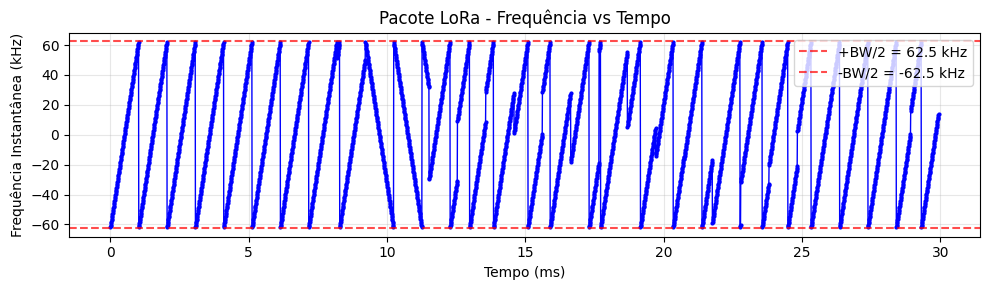

Frequência instantânea calculada para 3743 amostras
Duração total analisada: 29.9 ms

Transmissor LoRa para Sionna implementado e testado com sucesso!


In [5]:
# Análise dos sinais gerados
packet_lengths = [tf.shape(packet)[0] for packet in tf.unstack(lora_packets)]
print(f"Comprimento dos pacotes: {[length.numpy() for length in packet_lengths]} samples")

# Calcular duração temporal dos pacotes
total_duration = packet_lengths[0].numpy() * transmitter.chip_duration.numpy()
print(f"Duração total do pacote: {total_duration*1000:.2f} ms")


# Análise de frequência vs tempo do pacote
print("\n" + "="*50)
print("Análise de frequência vs tempo:")

try:
    # Usar o primeiro pacote do batch para análise detalhada
    single_packet_for_analysis = lora_packets[0]
    freq_inst, time_axis = transmitter.plot_frequency_vs_time(
        single_packet_for_analysis,
        "Pacote LoRa - Frequência vs Tempo"
    )

    print(f"Frequência instantânea calculada para {len(freq_inst)} amostras")
    print(f"Duração total analisada: {time_axis[-1]:.1f} ms")

    # # Usar o primeiro pacote do batch para análise detalhada
    # single_packet_for_analysis = lora_packets[1]
    # freq_inst, time_axis = transmitter.plot_frequency_vs_time(
    #     single_packet_for_analysis,
    #     "Pacote 2 LoRa - Frequência vs Tempo"
    # )

    # print(f"Frequência instantânea calculada para {len(freq_inst)} amostras")
    # print(f"Duração total analisada: {time_axis[-1]:.1f} ms")

    # Análise estrutural completa
    #sections = transmitter.analyze_lora_packet_structure(single_packet_for_analysis)

except Exception as e:
    print(f"Erro na análise de frequência: {e}")
    import traceback
    traceback.print_exc()

print("\nTransmissor LoRa para Sionna implementado e testado com sucesso!")

#### Análise de Eficiência Computacional

Testes de dempenho

TESTE -> Análise de Tempo de processamento x Batch size:

CELL 1 — PROCESSING TIME BENCHMARK × BATCH SIZE
  Device detected : GPU (physical_device:GPU:0)
  Logical CPUs    : 12
  Total RAM       : 7.7 GB

TIME BENCHMARK × BATCH SIZE
  (complete pipeline — includes tf.map_fn parallelism)

  Batch size = 1 packets
  ------------------------------------------------
LoRa Transmitter configurado para entrada: (1, 80)
    Total time  : 14.43 ± 1.64 ms
    Per packet  : 14.43 ms  |  Throughput: 69.3 pkt/s

  Batch size = 10 packets
  ------------------------------------------------
    Total time  : 13.59 ± 2.26 ms
    Per packet  : 1.36 ms  |  Throughput: 735.6 pkt/s

  Batch size = 50 packets
  ------------------------------------------------
    Total time  : 13.78 ± 2.31 ms
    Per packet  : 0.28 ms  |  Throughput: 3629.2 pkt/s

  Batch size = 100 packets
  ------------------------------------------------
    Total time  : 13.66 ± 1.09 ms
    Per packet  : 0.14 ms  |  Throughput: 7318.7 pkt/s

  Batch size = 200 packets
  -----------------------

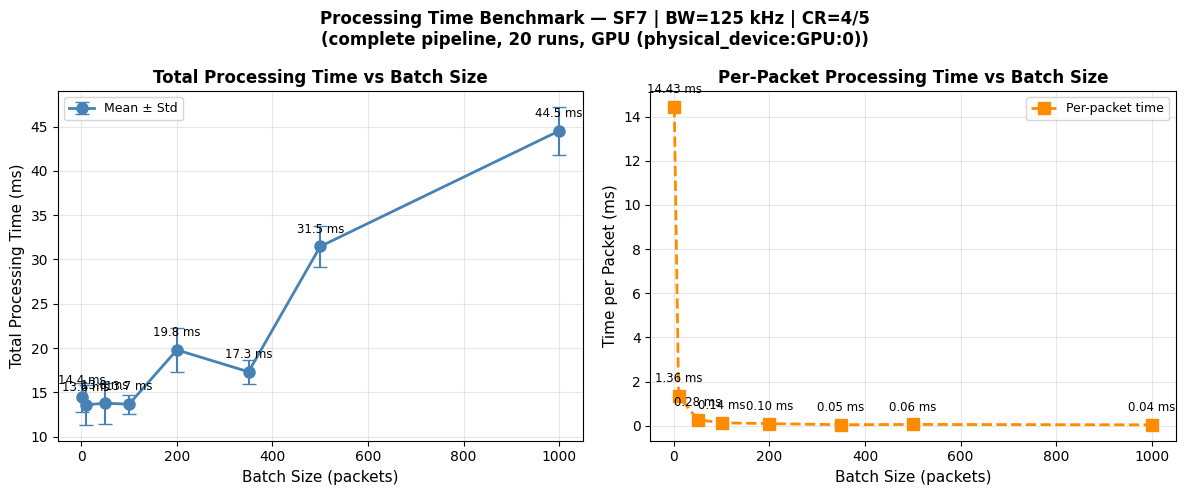

✅ Figure saved: lora_time_benchmark.png


In [7]:
# ===================================================================
# CELL 1 — PROCESSING TIME BENCHMARK × BATCH SIZE
# LoRa Transmitter — Sionna/TensorFlow
#
# Measures total and per-packet processing time across different
# batch sizes using the complete tx pipeline (tf.map_fn parallel).
# ===================================================================

import time
import os
import threading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import psutil

# ───────────────────────────────────────────────────────────────────
# HARDWARE DETECTION
# ───────────────────────────────────────────────────────────────────

_PROCESS    = psutil.Process(os.getpid())
_GPUS       = tf.config.list_physical_devices('GPU')
_HAS_GPU    = len(_GPUS) > 0
_DEVICE_STR = f"GPU ({_GPUS[0].name.split('/')[-1]})" if _HAS_GPU else "CPU only"

print("=" * 70)
print("CELL 1 — PROCESSING TIME BENCHMARK × BATCH SIZE")
print(f"  Device detected : {_DEVICE_STR}")
print(f"  Logical CPUs    : {psutil.cpu_count(logical=True)}")
print(f"  Total RAM       : {psutil.virtual_memory().total / 1024**3:.1f} GB")
print("=" * 70)

# ───────────────────────────────────────────────────────────────────
# GLOBAL PARAMETERS
# ───────────────────────────────────────────────────────────────────

NUM_RUNS   = 20   # repetitions per measurement (averaged)
NUM_WARMUP = 10    # warm-up runs (discarded)
NUM_BITS   = 80   # bits/payload (10 bytes)

LORA_CONFIG = {
    'spreading_factor': 7,
    'bandwidth': 125e3,
    'coding_rate': 1,
    'crc_on': True,
    'debug': False,
}

# BATCH_SIZES = [10, 100, 200]
BATCH_SIZES = [1, 10, 50, 100, 200, 350, 500, 1000]

# ───────────────────────────────────────────────────────────────────
# HELPER: force GPU sync (materialise tensor)
# ───────────────────────────────────────────────────────────────────

def _sync_result(result):
    """Forces GPU synchronisation by materialising the tensor."""
    if isinstance(result, tf.Tensor):
        result.numpy()
    elif isinstance(result, (list, tuple)):
        for r in result:
            if isinstance(r, tf.Tensor):
                r.numpy()
                break


# ───────────────────────────────────────────────────────────────────
# TIMING MEASUREMENT FUNCTION
# ───────────────────────────────────────────────────────────────────

def measure_time(fn, *args, num_runs=NUM_RUNS, num_warmup=NUM_WARMUP) -> dict:
    """
    Measures execution time of a TF function.

    Parameters
    ----------
    fn         : callable — function to measure
    *args      : arguments for fn
    num_runs   : int — measurement runs (averaged)
    num_warmup : int — warm-up runs (discarded, forces JIT / @tf.function compile)

    Returns
    -------
    dict with: time_mean_ms, time_std_ms, time_min_ms, time_max_ms
    """
    # Warm-up: force JIT / @tf.function compilation
    for _ in range(num_warmup):
        r = fn(*args)
        _sync_result(r)

    # Timed runs
    times_ms = []
    for _ in range(num_runs):
        t0 = time.perf_counter()
        r = fn(*args)
        _sync_result(r)   # sync before stopping the clock
        t1 = time.perf_counter()
        times_ms.append((t1 - t0) * 1000.0)

    return {
        'time_mean_ms': float(np.mean(times_ms)),
        'time_std_ms':  float(np.std(times_ms)),
        'time_min_ms':  float(np.min(times_ms)),
        'time_max_ms':  float(np.max(times_ms)),
    }


# ───────────────────────────────────────────────────────────────────
# BENCHMARK LOOP
# ───────────────────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("TIME BENCHMARK × BATCH SIZE")
print("  (complete pipeline — includes tf.map_fn parallelism)")
print("=" * 70)

tx_bench = LoRaPhyTransmitter(**LORA_CONFIG)
benchmark_records = []

for bs in BATCH_SIZES:
    print(f"\n  Batch size = {bs} packets")
    print("  " + "-" * 48)

    bits = binary_source([bs, NUM_BITS])
    m = measure_time(tx_bench, bits, num_runs=NUM_RUNS, num_warmup=NUM_WARMUP)

    per_pkt_ms = m['time_mean_ms'] / bs
    throughput  = bs / (m['time_mean_ms'] / 1000.0)

    benchmark_records.append({
        'batch_size':   bs,
        'total_ms':     m['time_mean_ms'],
        'total_std_ms': m['time_std_ms'],
        'per_pkt_ms':   per_pkt_ms,
        'throughput':   throughput,
    })

    print(f"    Total time  : {m['time_mean_ms']:.2f} ± {m['time_std_ms']:.2f} ms")
    print(f"    Per packet  : {per_pkt_ms:.2f} ms  |  Throughput: {throughput:.1f} pkt/s")

df_bench_time = pd.DataFrame(benchmark_records)

# Tabular summary
print("\n" + "=" * 70)
print("SUMMARY — TIME BENCHMARK")
print("=" * 70)
cols = ['batch_size', 'total_ms', 'total_std_ms', 'per_pkt_ms', 'throughput']
print(df_bench_time[cols].to_string(index=False, float_format=lambda x: f"{x:.2f}"))


# ───────────────────────────────────────────────────────────────────
# PLOT — Processing Time vs Batch Size
# ───────────────────────────────────────────────────────────────────

cfg = LORA_CONFIG
bs_vals = df_bench_time['batch_size'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Total processing time ---
ax = axes[0]
ax.errorbar(
    bs_vals,
    df_bench_time['total_ms'],
    yerr=df_bench_time['total_std_ms'],
    fmt='o-', color='steelblue', linewidth=2, markersize=8,
    capsize=5, elinewidth=1.5, label='Mean ± Std'
)
ax.set_xlabel('Batch Size (packets)', fontsize=11)
ax.set_ylabel('Total Processing Time (ms)', fontsize=11)
ax.set_title('Total Processing Time vs Batch Size', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
for x, y, s in zip(bs_vals, df_bench_time['total_ms'], df_bench_time['total_std_ms']):
    ax.annotate(f'{y:.1f} ms', (x, y),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8.5)

# --- Right: Per-packet processing time ---
ax = axes[1]
ax.plot(bs_vals, df_bench_time['per_pkt_ms'], 's--', color='darkorange',
        linewidth=2, markersize=8, label='Per-packet time')
ax.set_xlabel('Batch Size (packets)', fontsize=11)
ax.set_ylabel('Time per Packet (ms)', fontsize=11)
ax.set_title('Per-Packet Processing Time vs Batch Size', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
for x, y in zip(bs_vals, df_bench_time['per_pkt_ms']):
    ax.annotate(f'{y:.2f} ms', (x, y),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8.5)

fig.suptitle(
    f"Processing Time Benchmark — SF{cfg['spreading_factor']} | "
    f"BW={int(cfg['bandwidth']/1e3)} kHz | CR=4/{4+cfg['coding_rate']}\n"
    f"(complete pipeline, {NUM_RUNS} runs, {_DEVICE_STR})",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('lora_time_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved: lora_time_benchmark.png")

df_bench_time.to_csv('sionna_time_benchmark.csv', index=False)

TESTE -> Análise de Recursos x Batch Size

CELL 2 — RESOURCE USAGE BENCHMARK × BATCH SIZE
  Device detected : GPU (physical_device:GPU:0)
  Logical CPUs    : 12
  Total RAM       : 7.7 GB

RESOURCE USAGE BENCHMARK × BATCH SIZE
  (complete pipeline — includes tf.map_fn parallelism)

  Batch size = 1 packets
  ------------------------------------------------
LoRa Transmitter configurado para entrada: (1, 80)
    CPU     : mean=94.7%  peak=1351.5%
    (>100% = multiple cores used by TF in parallel)
    RAM     : mean=1135 MB  peak=1135 MB
    GPU mem : mean=0.1 MB  peak=0.1 MB

  Batch size = 10 packets
  ------------------------------------------------
    CPU     : mean=95.9%  peak=1157.2%
    (>100% = multiple cores used by TF in parallel)
    RAM     : mean=1143 MB  peak=1143 MB
    GPU mem : mean=0.5 MB  peak=0.5 MB

  Batch size = 50 packets
  ------------------------------------------------
    CPU     : mean=220.4%  peak=1171.3%
    (>100% = multiple cores used by TF in parallel)
    RAM     : mean=1156 MB  peak=1156 MB
  

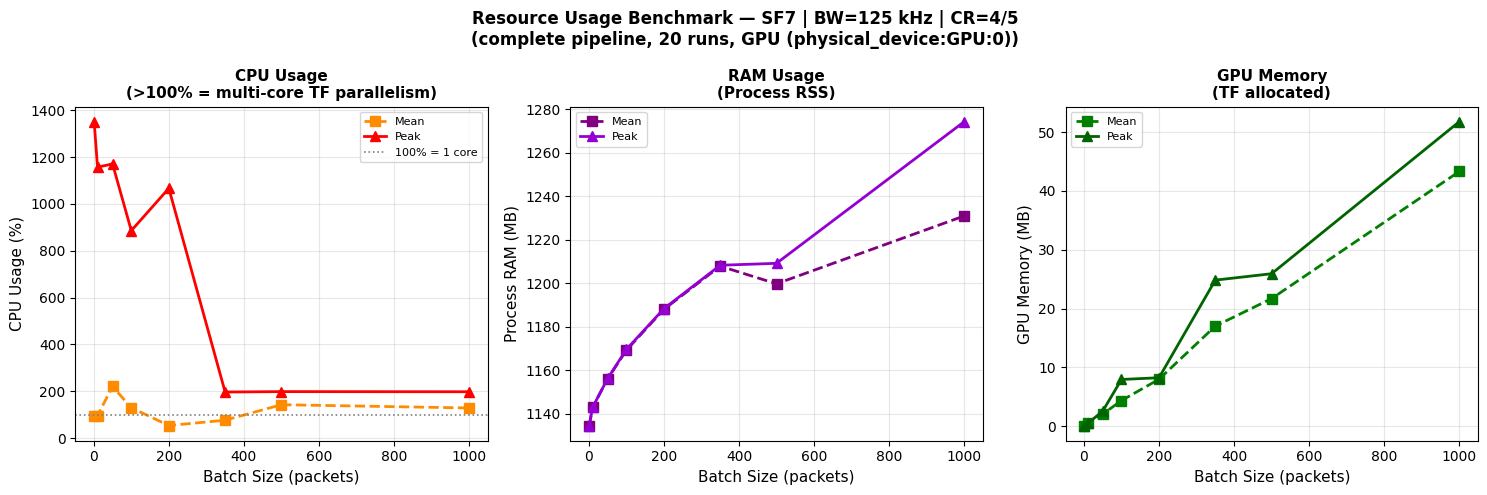

✅ Figure saved: lora_resource_benchmark.png


In [8]:
# ===================================================================
# CELL 2 — RESOURCE USAGE BENCHMARK × BATCH SIZE
# LoRa Transmitter — Sionna/TensorFlow
#
# NOTE on resource monitoring in parallel batches:
# ─────────────────────────────────────────────────────
# The `call` method uses `tf.map_fn(..., parallel_iterations=batch_size)`,
# which distributes packet processing across internal TF threads.
# This has two direct effects:
#
#   1. CPU: psutil measures the entire Python process. Since TF uses
#      multiple internal C++ threads (Eigen, BLAS, CUDA streams),
#      CPU% can exceed 100% (represents the sum of all cores).
#      This is expected and correct — it shows real parallelism.
#
#   2. GPU: tf.config.experimental.get_memory_info() only captures
#      allocations within the Python/TF context. Async GPU operations
#      may have already been freed when we read the peak. Therefore
#      we sample DURING and AFTER execution.
#
#   3. RAM: psutil measures RSS (Resident Set Size) of the process,
#      which includes the Python interpreter, TF runtime, and all
#      allocated tensors. It is the most reliable resource metric here.
# ===================================================================

import time
import os
import threading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import psutil

# ───────────────────────────────────────────────────────────────────
# HARDWARE DETECTION
# ───────────────────────────────────────────────────────────────────

_PROCESS    = psutil.Process(os.getpid())
_GPUS       = tf.config.list_physical_devices('GPU')
_HAS_GPU    = len(_GPUS) > 0
_DEVICE_STR = f"GPU ({_GPUS[0].name.split('/')[-1]})" if _HAS_GPU else "CPU only"

print("=" * 70)
print("CELL 2 — RESOURCE USAGE BENCHMARK × BATCH SIZE")
print(f"  Device detected : {_DEVICE_STR}")
print(f"  Logical CPUs    : {psutil.cpu_count(logical=True)}")
print(f"  Total RAM       : {psutil.virtual_memory().total / 1024**3:.1f} GB")
print("=" * 70)

# ───────────────────────────────────────────────────────────────────
# GLOBAL PARAMETERS
# ───────────────────────────────────────────────────────────────────

NUM_RUNS   = 20
NUM_WARMUP = 10
NUM_BITS   = 80

LORA_CONFIG = {
    'spreading_factor': 7,
    'bandwidth': 125e3,
    'coding_rate': 1,
    'crc_on': True,
    'debug': False,
}

# BATCH_SIZES = [10, 100, 200]
BATCH_SIZES = [1, 10, 50, 100, 200, 350, 500, 1000]


# ───────────────────────────────────────────────────────────────────
# CONTINUOUS RESOURCE MONITOR (separate thread)
# ───────────────────────────────────────────────────────────────────

class ResourceMonitor:
    """
    Samples CPU%, RAM and GPU memory in a separate thread
    while the target function runs.

    Usage:
        mon = ResourceMonitor(interval_s=0.02)
        mon.start()
        ... run target function ...
        mon.stop()
        stats = mon.stats()   # dict with means and peaks
    """

    def __init__(self, interval_s: float = 0.02):
        self.interval_s    = interval_s
        self._cpu_samples  : list[float] = []
        self._ram_samples  : list[float] = []   # MB
        self._gpu_samples  : list[float] = []   # MB
        self._stop_event   = threading.Event()
        self._thread       = threading.Thread(target=self._run, daemon=True)

    def start(self):
        self._stop_event.clear()
        self._cpu_samples.clear()
        self._ram_samples.clear()
        self._gpu_samples.clear()
        self._thread = threading.Thread(target=self._run, daemon=True)
        self._thread.start()

    def stop(self):
        self._stop_event.set()
        self._thread.join(timeout=2.0)

    def _run(self):
        # Prime psutil CPU counter (first call returns 0.0 by design)
        _PROCESS.cpu_percent(interval=None)
        while not self._stop_event.is_set():
            # cpu_percent(interval=None) returns utilisation since last call.
            # We store the raw per-process value; >100% is expected on
            # multi-core machines when TF uses multiple threads.
            self._cpu_samples.append(
                _PROCESS.cpu_percent(interval=None)
            )
            # RSS: bytes → MB
            self._ram_samples.append(
                _PROCESS.memory_info().rss / 1024**2
            )
            if _HAS_GPU:
                try:
                    info = tf.config.experimental.get_memory_info('GPU:0')
                    self._gpu_samples.append(info['current'] / 1024**2)
                except Exception:
                    pass
            time.sleep(self.interval_s)

    def stats(self) -> dict:
        """Returns statistics from collected samples."""
        def _s(lst):
            if not lst:
                return {'mean': 0.0, 'peak': 0.0, 'std': 0.0}
            a = np.array(lst, dtype=float)
            # Drop the first sample (CPU counter priming artifact)
            if len(a) > 1:
                a = a[1:]
            return {'mean': float(a.mean()), 'peak': float(a.max()), 'std': float(a.std())}

        return {
            'cpu':      _s(self._cpu_samples),   # % (can exceed 100% on multi-core)
            'ram':      _s(self._ram_samples),   # MB
            'gpu':      _s(self._gpu_samples),   # MB (empty if no GPU)
            'n_samples': len(self._cpu_samples),
        }


# ───────────────────────────────────────────────────────────────────
# RESOURCE MEASUREMENT FUNCTION
# ───────────────────────────────────────────────────────────────────

def _sync_result(result):
    """Forces GPU synchronisation by materialising the tensor."""
    if isinstance(result, tf.Tensor):
        result.numpy()
    elif isinstance(result, (list, tuple)):
        for r in result:
            if isinstance(r, tf.Tensor):
                r.numpy()
                break


def measure_resources(fn, *args,
                      num_runs=NUM_RUNS,
                      num_warmup=NUM_WARMUP,
                      monitor_interval=0.02) -> dict:
    """
    Measures CPU / RAM / GPU usage of a TF function.

    Parameters
    ----------
    fn               : callable — function to measure
    *args            : arguments for fn
    num_runs         : int — measurement runs (averaged)
    num_warmup       : int — warm-up runs (forces JIT / @tf.function compile)
    monitor_interval : float — resource sampling interval in seconds

    Returns
    -------
    dict with:
      cpu_mean_pct, cpu_peak_pct
      ram_mean_mb,  ram_peak_mb
      gpu_mean_mb,  gpu_peak_mb  (0.0 if no GPU)
    """
    # Warm-up
    for _ in range(num_warmup):
        r = fn(*args)
        _sync_result(r)

    monitor = ResourceMonitor(interval_s=monitor_interval)
    all_stats = []

    for _ in range(num_runs):
        if _HAS_GPU:
            try:
                tf.config.experimental.reset_memory_stats('GPU:0')
            except Exception:
                pass

        monitor.start()
        r = fn(*args)
        _sync_result(r)          # sync before stopping monitor
        monitor.stop()

        all_stats.append(monitor.stats())

    # Aggregate resource statistics across runs
    cpu_means = [s['cpu']['mean'] for s in all_stats]
    cpu_peaks = [s['cpu']['peak'] for s in all_stats]
    ram_means = [s['ram']['mean'] for s in all_stats]
    ram_peaks = [s['ram']['peak'] for s in all_stats]
    gpu_means = [s['gpu']['mean'] for s in all_stats if s['gpu']['mean'] > 0]
    gpu_peaks = [s['gpu']['peak'] for s in all_stats if s['gpu']['peak'] > 0]

    return {
        'cpu_mean_pct': float(np.mean(cpu_means)) if cpu_means else 0.0,
        'cpu_peak_pct': float(np.max(cpu_peaks))  if cpu_peaks else 0.0,
        'ram_mean_mb':  float(np.mean(ram_means)) if ram_means else 0.0,
        'ram_peak_mb':  float(np.max(ram_peaks))  if ram_peaks else 0.0,
        'gpu_mean_mb':  float(np.mean(gpu_means)) if gpu_means else 0.0,
        'gpu_peak_mb':  float(np.max(gpu_peaks))  if gpu_peaks else 0.0,
    }


# ───────────────────────────────────────────────────────────────────
# BENCHMARK LOOP
# ───────────────────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("RESOURCE USAGE BENCHMARK × BATCH SIZE")
print("  (complete pipeline — includes tf.map_fn parallelism)")
print("=" * 70)

tx_bench = LoRaPhyTransmitter(**LORA_CONFIG)
benchmark_records = []

for bs in BATCH_SIZES:
    print(f"\n  Batch size = {bs} packets")
    print("  " + "-" * 48)

    bits = binary_source([bs, NUM_BITS])
    m = measure_resources(tx_bench, bits, num_runs=NUM_RUNS, num_warmup=NUM_WARMUP)

    benchmark_records.append({
        'batch_size':   bs,
        'cpu_mean_pct': m['cpu_mean_pct'],
        'cpu_peak_pct': m['cpu_peak_pct'],
        'ram_mean_mb':  m['ram_mean_mb'],
        'ram_peak_mb':  m['ram_peak_mb'],
        'gpu_mean_mb':  m['gpu_mean_mb'],
        'gpu_peak_mb':  m['gpu_peak_mb'],
    })

    print(f"    CPU     : mean={m['cpu_mean_pct']:.1f}%  peak={m['cpu_peak_pct']:.1f}%")
    print(f"    (>100% = multiple cores used by TF in parallel)")
    print(f"    RAM     : mean={m['ram_mean_mb']:.0f} MB  peak={m['ram_peak_mb']:.0f} MB")
    if _HAS_GPU:
        print(f"    GPU mem : mean={m['gpu_mean_mb']:.1f} MB  peak={m['gpu_peak_mb']:.1f} MB")

df_bench_res = pd.DataFrame(benchmark_records)

# Tabular summary
print("\n" + "=" * 70)
print("SUMMARY — RESOURCE BENCHMARK")
print("=" * 70)
cols = ['batch_size', 'cpu_mean_pct', 'cpu_peak_pct',
        'ram_mean_mb', 'ram_peak_mb', 'gpu_mean_mb', 'gpu_peak_mb']
print(df_bench_res[cols].to_string(index=False, float_format=lambda x: f"{x:.2f}"))


# ───────────────────────────────────────────────────────────────────
# PLOT — Resource Usage vs Batch Size
# ───────────────────────────────────────────────────────────────────

cfg = LORA_CONFIG
bs_vals = df_bench_res['batch_size'].values

# n_cols = 3 if not _HAS_GPU else 4
n_cols = 2 if not _HAS_GPU else 3
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

# --- CPU ---
ax = axes[0]
ax.plot(bs_vals, df_bench_res['cpu_mean_pct'], 's--', color='darkorange',
        linewidth=2, markersize=7, label='Mean')
ax.plot(bs_vals, df_bench_res['cpu_peak_pct'], '^-', color='red',
        linewidth=2, markersize=7, label='Peak')
ax.axhline(100, color='gray', linestyle=':', linewidth=1.2,
           label='100% = 1 core')
ax.set_xlabel('Batch Size (packets)', fontsize=11)
ax.set_ylabel('CPU Usage (%)', fontsize=11)
ax.set_title('CPU Usage\n(>100% = multi-core TF parallelism)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- RAM ---
ax = axes[1]
ax.plot(bs_vals, df_bench_res['ram_mean_mb'], 's--', color='purple',
        linewidth=2, markersize=7, label='Mean')
ax.plot(bs_vals, df_bench_res['ram_peak_mb'], '^-', color='darkviolet',
        linewidth=2, markersize=7, label='Peak')
ax.set_xlabel('Batch Size (packets)', fontsize=11)
ax.set_ylabel('Process RAM (MB)', fontsize=11)
ax.set_title('RAM Usage\n(Process RSS)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- GPU (only if available) ---
if _HAS_GPU:
    ax = axes[2]
    ax.plot(bs_vals, df_bench_res['gpu_mean_mb'], 's--', color='green',
            linewidth=2, markersize=7, label='Mean')
    ax.plot(bs_vals, df_bench_res['gpu_peak_mb'], '^-', color='darkgreen',
            linewidth=2, markersize=7, label='Peak')
    ax.set_xlabel('Batch Size (packets)', fontsize=11)
    ax.set_ylabel('GPU Memory (MB)', fontsize=11)
    ax.set_title('GPU Memory\n(TF allocated)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
#     ax_notes = axes[3]
# else:
#     ax_notes = axes[2]

# --- Annotation panel: measurement notes ---
# ax_notes.axis('off')
# notes = (
#     "Measurement notes\n"
#     "─────────────────\n\n"
#     "CPU (%):\n"
#     "  psutil measures the entire Python\n"
#     "  process. TF uses multiple C++ threads\n"
#     "  (Eigen/BLAS), so >100% is expected\n"
#     "  and reflects real multi-core parallelism.\n\n"
#     "RAM (MB):\n"
#     "  RSS (Resident Set Size) of the process.\n"
#     "  Includes Python interpreter, TF runtime\n"
#     "  and all allocated tensors.\n\n"
#     "GPU (MB):\n"
#     "  tf.config.experimental.get_memory_info\n"
#     "  captures current TF allocations.\n"
#     "  Async ops may show lower peaks than\n"
#     "  actual GPU usage."
# )
# ax_notes.text(0.02, 0.98, notes,
#               transform=ax_notes.transAxes,
#               fontsize=8.5, verticalalignment='top',
#               fontfamily='monospace',
#               bbox=dict(boxstyle='round', facecolor='lightyellow',
#                         edgecolor='gray', alpha=0.7))

fig.suptitle(
    f"Resource Usage Benchmark — SF{cfg['spreading_factor']} | "
    f"BW={int(cfg['bandwidth']/1e3)} kHz | CR=4/{4+cfg['coding_rate']}\n"
    f"(complete pipeline, {NUM_RUNS} runs, {_DEVICE_STR})",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('lora_resource_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved: lora_resource_benchmark.png")

df_bench_res.to_csv('sionna_resource_benchmark.csv', index=False)

TESTE -> Análise por Etapa 

STEP-BY-STEP PROFILING — LoRaPhyTransmitter (batch-paralela)
  Device detected : GPU (physical_device:GPU:0)

  Configurando transmissor (SF=7, BW=125 kHz, CR=4/5)...
  Transmissor criado
  Bits por payload : 80 (10 bytes)
  Batch size (modo B) : 100
  Runs/estágio : 20 medições + 10 warm-up

MODO A — batch = 1  (comparável com versão original map_fn)

  > 0a. Preâmbulo (_compute_preamble — init only)
    3.455 ± 1.066 ms

  > 0b. Sync Word (_compute_sync_word — init only)
    1.337 ± 0.868 ms

  > 0c. Down-Chirps (_compute_down_chirps — init only)
    3.491 ± 0.920 ms

  > 1. Whitening
    1.160 ± 0.722 ms

  > 2. Header (generate_header_batch)
    2.413 ± 1.093 ms

  > 3. CRC (add_lora_crc_batch)
    2.434 ± 1.253 ms

  > 4. Hamming Encode (hamming_encode_batch)
    7.413 ± 4.187 ms

  > 5. Interleaving (interleaving_batch)
    2.499 ± 0.809 ms

  > 6. Gray + Chirp Mod (encode_data_batch)
    4.325 ± 1.091 ms

  > 7. call() completo (pipeline end-to-end)
LoRa Transmitter configurado 

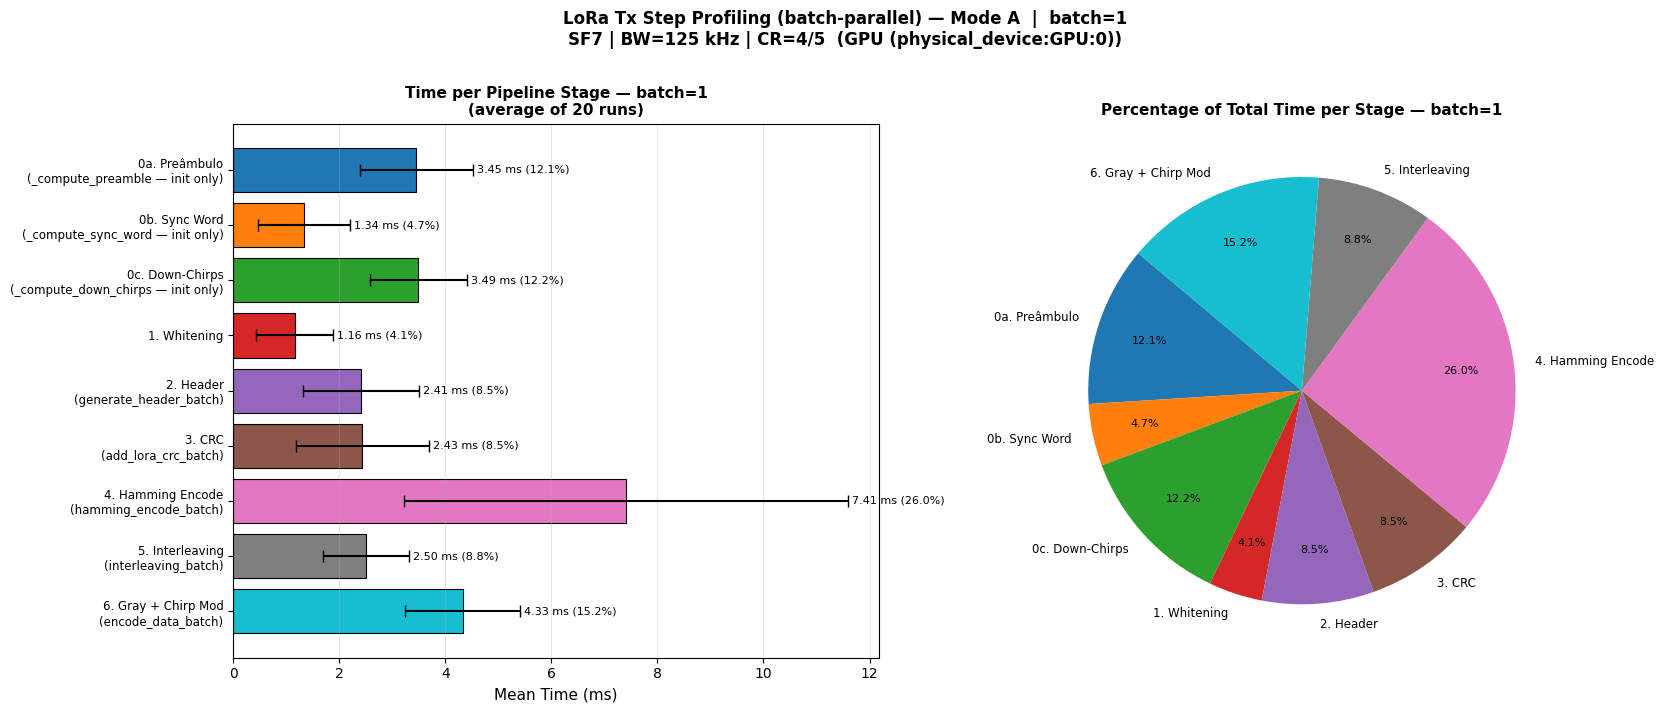

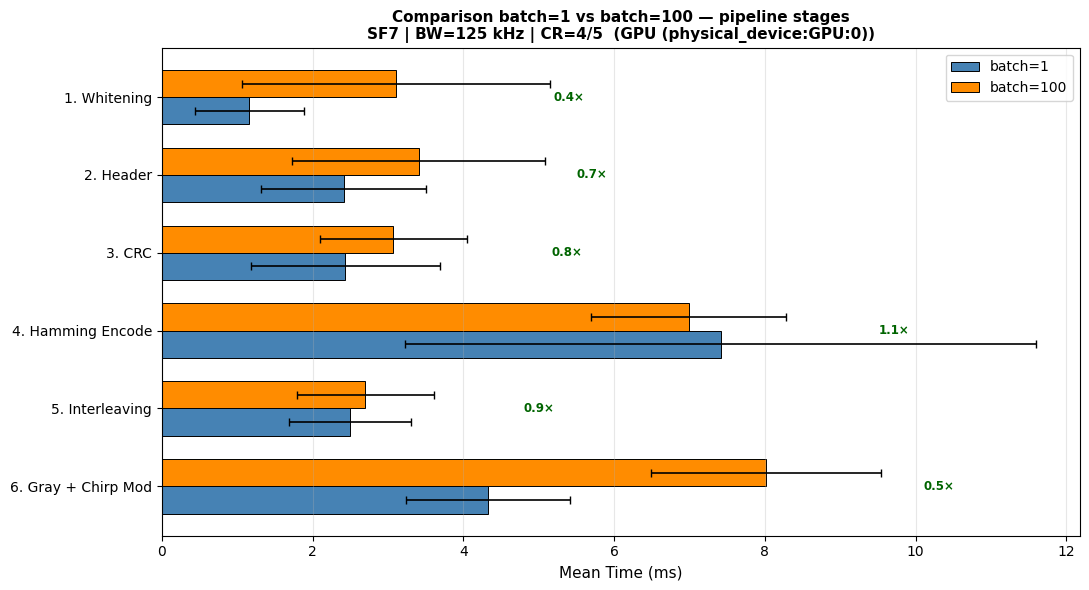


✅ Figuras salvas:
   lora_profiling_batch1.png
   lora_profiling_batch_comparison.png

✅ Profiling completo!


In [9]:
# ===================================================================
# STEP-BY-STEP PROFILING — LoRaPhyTransmitter (versão batch-paralela)
#
# Adaptado da versão original para a nova API batch:
#   - Todas as funções de estágio recebem [B, N] (batch dimension explícita)
#   - Preâmbulo / sync / down-chirps são pré-computados no __init__ e
#     não são mais estágios do pipeline em tempo de execução; são medidos
#     separadamente como "custo de inicialização" para referência.
#   - Novos nomes de métodos:
#       whitening              → whitening            (agora [B,N]→[B,N])
#       generate_header        → generate_header_batch([B]→[B,20])
#       add_lora_crc           → add_lora_crc_batch   ([B,N]→[B,16])
#       hamming_encode_tensor  → hamming_encode_batch ([B,N]→[B,N_coded])
#       interleaving           → interleaving_batch   ([B,N]→[B,N_sym])
#       encode_data_tensor     → encode_data_batch    ([B,N_sym]→[B,N_sym,n_chips])
#
# Dois modos de medição:
#   A) batch=1  — comparável à versão original
#   B) batch=BATCH_SIZE — mostra o ganho real do paralelismo
# ===================================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# ───────────────────────────────────────────────────────────────────
# HARDWARE DETECTION
# ───────────────────────────────────────────────────────────────────

_GPUS       = tf.config.list_physical_devices('GPU')
_HAS_GPU    = len(_GPUS) > 0
_DEVICE_STR = (f"GPU ({_GPUS[0].name.split('/')[-1]})"
               if _HAS_GPU else "CPU only")

print("=" * 70)
print("STEP-BY-STEP PROFILING — LoRaPhyTransmitter (batch-paralela)")
print(f"  Device detected : {_DEVICE_STR}")
print("=" * 70)

# ───────────────────────────────────────────────────────────────────
# GLOBAL PARAMETERS
# ───────────────────────────────────────────────────────────────────

NUM_RUNS   = 20
NUM_WARMUP = 10
NUM_BITS   = 80        # bits/payload  (10 bytes)
BATCH_SIZE = 100        # batch size para o modo B

LORA_CONFIG = {
    'spreading_factor': 7,
    'bandwidth': 125e3,
    'coding_rate': 1,
    'crc_on': True,
    'debug': False,
}

# ───────────────────────────────────────────────────────────────────
# HELPERS
# ───────────────────────────────────────────────────────────────────

def _sync_result(result):
    """Força sincronização GPU materializando o tensor."""
    if isinstance(result, tf.Tensor):
        result.numpy()
    elif isinstance(result, (list, tuple)):
        for r in result:
            if isinstance(r, tf.Tensor):
                r.numpy()
                break


def measure_step(fn, *args, num_runs=NUM_RUNS, num_warmup=NUM_WARMUP) -> dict:
    """
    Mede o tempo médio de execução de um estágio isolado.

    Parâmetros
    ----------
    fn         : callable  — função do estágio a medir
    *args      : argumentos para fn
    num_runs   : int  — repetições para média
    num_warmup : int  — warm-up (descartado; força compilação @tf.function)

    Retorna
    -------
    dict: mean_ms, std_ms, min_ms, max_ms
    """
    for _ in range(num_warmup):
        _sync_result(fn(*args))

    times_ms = []
    for _ in range(num_runs):
        t0 = time.perf_counter()
        r  = fn(*args)
        _sync_result(r)
        times_ms.append((time.perf_counter() - t0) * 1000.0)

    return {
        'mean_ms': float(np.mean(times_ms)),
        'std_ms':  float(np.std(times_ms)),
        'min_ms':  float(np.min(times_ms)),
        'max_ms':  float(np.max(times_ms)),
    }


def _measure(records, name, fn, *args):
    print(f"\n  > {name.replace(chr(10), ' ')}")
    m = measure_step(fn, *args)
    print(f"    {m['mean_ms']:.3f} ± {m['std_ms']:.3f} ms")
    records.append({'stage': name, **m})
    return m


# ───────────────────────────────────────────────────────────────────
# SETUP
# ───────────────────────────────────────────────────────────────────

cfg = LORA_CONFIG
print(f"\n  Configurando transmissor "
      f"(SF={cfg['spreading_factor']}, "
      f"BW={int(cfg['bandwidth']/1e3)} kHz, "
      f"CR=4/{4+cfg['coding_rate']})...")

tx = LoRaPhyTransmitter(**LORA_CONFIG)

# Payloads: [1, N] para modo A  |  [B, N] para modo B
bits_b1 = tf.cast(binary_source([1, NUM_BITS]),         tf.int32)  # [1,  N]
bits_bN = tf.cast(binary_source([BATCH_SIZE, NUM_BITS]), tf.int32)  # [B,  N]

print(f"  Transmissor criado")
print(f"  Bits por payload : {NUM_BITS} ({NUM_BITS // 8} bytes)")
print(f"  Batch size (modo B) : {BATCH_SIZE}")
print(f"  Runs/estágio : {NUM_RUNS} medições + {NUM_WARMUP} warm-up")


# ═══════════════════════════════════════════════════════════════════
# MODO A — batch = 1  (comparável à versão original)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print(f"MODO A — batch = 1  (comparável com versão original map_fn)")
print("=" * 70)

records_a = []

# ── Custos de inicialização (pré-computados no __init__) ──────────
# Na nova versão, preâmbulo/sync/down-chirps são constantes TF criadas
# no __init__ via _compute_preamble / _compute_sync_word / _compute_down_chirps.
# Medimos o custo de recriá-los como referência (não ocorre no call()).
_measure(records_a,
         "0a. Preâmbulo\n(_compute_preamble — init only)",
         tx._compute_preamble)

_measure(records_a,
         "0b. Sync Word\n(_compute_sync_word — init only)",
         tx._compute_sync_word)

_measure(records_a,
         "0c. Down-Chirps\n(_compute_down_chirps — init only)",
         tx._compute_down_chirps)

# ── Estágios do pipeline (chamados em call()) ─────────────────────

# 1. Whitening  [1, N] → [1, N]
_measure(records_a, "1. Whitening", tx.whitening, bits_b1)

whitened_a = tx.whitening(bits_b1)                                 # [1, N]
lengths_a  = tf.constant([NUM_BITS], dtype=tf.int32)               # [1]

# 2. Header  [1] → [1, 20]
_measure(records_a,
         "2. Header\n(generate_header_batch)",
         tx.generate_header_batch, lengths_a)

headers_a = tx.generate_header_batch(lengths_a)                    # [1, 20]

# 3. CRC  [1, N] → [1, 16]
_measure(records_a,
         "3. CRC\n(add_lora_crc_batch)",
         tx.add_lora_crc_batch, bits_b1)

crc_a = tx.add_lora_crc_batch(bits_b1)                             # [1, 16]

# Frame: header + whitened_payload + crc  → [1, 20+N+16]
frame_a = tf.concat([headers_a, whitened_a, crc_a], axis=1)

# 4. Hamming  [1, 20+N+16] → [1, N_coded]
_measure(records_a,
         "4. Hamming Encode\n(hamming_encode_batch)",
         tx.hamming_encode_batch, frame_a)

coded_a = tx.hamming_encode_batch(frame_a)                         # [1, N_coded]

# 5. Interleaving  [1, N_coded] → [1, N_sym]
_measure(records_a,
         "5. Interleaving\n(interleaving_batch)",
         tx.interleaving_batch, coded_a)

symbols_a = tx.interleaving_batch(coded_a)                         # [1, N_sym]

# 6. Gray + Chirp Modulation  [1, N_sym] → [1, N_sym, n_chips]
_measure(records_a,
         "6. Gray + Chirp Mod\n(encode_data_batch)",
         tx.encode_data_batch, symbols_a)

# 7. call() completo — inclui montagem do pacote e broadcast do batch
_measure(records_a,
         "7. call() completo\n(pipeline end-to-end)",
         tx, bits_b1)


# ═══════════════════════════════════════════════════════════════════
# MODO B — batch = BATCH_SIZE  (ganho real de paralelismo)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print(f"MODO B — batch = {BATCH_SIZE}  (paralelismo batch)")
print("=" * 70)

records_b = []

_measure(records_b, "1. Whitening", tx.whitening, bits_bN)

whitened_b = tx.whitening(bits_bN)
lengths_b  = tf.fill([BATCH_SIZE], NUM_BITS)

_measure(records_b,
         "2. Header\n(generate_header_batch)",
         tx.generate_header_batch, lengths_b)

headers_b = tx.generate_header_batch(lengths_b)
crc_b     = tx.add_lora_crc_batch(bits_bN)

_measure(records_b,
         "3. CRC\n(add_lora_crc_batch)",
         tx.add_lora_crc_batch, bits_bN)

frame_b = tf.concat([headers_b, whitened_b, crc_b], axis=1)

_measure(records_b,
         "4. Hamming Encode\n(hamming_encode_batch)",
         tx.hamming_encode_batch, frame_b)

coded_b = tx.hamming_encode_batch(frame_b)

_measure(records_b,
         "5. Interleaving\n(interleaving_batch)",
         tx.interleaving_batch, coded_b)

symbols_b = tx.interleaving_batch(coded_b)

_measure(records_b,
         "6. Gray + Chirp Mod\n(encode_data_batch)",
         tx.encode_data_batch, symbols_b)

_measure(records_b,
         f"7. call() completo\n(pipeline end-to-end, B={BATCH_SIZE})",
         tx, bits_bN)


# ═══════════════════════════════════════════════════════════════════
# TABELAS RESUMO
# ═══════════════════════════════════════════════════════════════════

def _print_table(records, title):
    df = pd.DataFrame(records)
    total = df['mean_ms'].sum()
    df['pct'] = (df['mean_ms'] / total * 100).round(1)
    print(f"\n{'='*70}")
    print(f"RESUMO — {title}")
    print(f"{'='*70}")
    hdr = f"{'Estágio':<48} {'Média(ms)':>10} {'Std(ms)':>9} {'%':>7}"
    print(hdr)
    print("-" * len(hdr))
    for _, row in df.iterrows():
        name = row['stage'].replace('\n', ' ')
        print(f"{name:<48} {row['mean_ms']:>10.3f} {row['std_ms']:>9.3f} "
              f"{row['pct']:>6.1f}%")
    print("-" * len(hdr))
    print(f"{'TOTAL (soma dos estágios)':<48} {total:>10.3f}")
    return df

df_a = _print_table(records_a, f"MODO A — batch=1")
df_b = _print_table(records_b, f"MODO B — batch={BATCH_SIZE}")

# Eficiência de paralelismo (estágios comuns, excluindo init-only e call())
pipeline_stages = ["1. Whitening",
                   "2. Header\n(generate_header_batch)",
                   "3. CRC\n(add_lora_crc_batch)",
                   "4. Hamming Encode\n(hamming_encode_batch)",
                   "5. Interleaving\n(interleaving_batch)",
                   "6. Gray + Chirp Mod\n(encode_data_batch)"]

total_a = df_a[df_a['stage'].isin(pipeline_stages)]['mean_ms'].sum()
total_b = df_b[df_b['stage'].isin(pipeline_stages)]['mean_ms'].sum()

print(f"\n  Tempo pipeline (estágios 1-6):")
print(f"    batch=1        : {total_a:.3f} ms")
print(f"    batch={BATCH_SIZE:<3}      : {total_b:.3f} ms")
if total_b > 0:
    speedup = total_a / total_b
    efficiency = speedup / BATCH_SIZE * 100
    print(f"    Speedup        : {speedup:.2f}×")
    print(f"    Eficiência GPU : {efficiency:.1f}%  (ideal=100%)")


# ═══════════════════════════════════════════════════════════════════
# FIGURAS
# ═══════════════════════════════════════════════════════════════════

COLORS = plt.cm.tab10(np.linspace(0, 0.9, max(len(df_a), len(df_b))))

# ── Figura 1: Modo A — bar + pie (pipeline stages only, no call()) ──
# Exclude the end-to-end call() entry so only individual stages are shown
df_a_steps = df_a[df_a['stage'].isin(pipeline_stages +
    [s for s in df_a['stage'] if s.startswith('0')])].copy()
# Recompute percentages relative to the filtered subset
df_a_steps['pct'] = (df_a_steps['mean_ms'] / df_a_steps['mean_ms'].sum() * 100).round(1)

fig1, axes1 = plt.subplots(1, 2, figsize=(17, 7))

labels_a_full  = df_a_steps['stage'].tolist()
labels_a_short = [s.split('\n')[0] for s in labels_a_full]
means_a  = df_a_steps['mean_ms'].values
stds_a   = df_a_steps['std_ms'].values
pcts_a   = df_a_steps['pct'].values
colors_a = plt.cm.tab10(np.linspace(0, 0.9, len(df_a_steps)))

ax = axes1[0]
bars = ax.barh(range(len(means_a)), means_a,
               xerr=stds_a, color=colors_a, edgecolor='black', linewidth=0.8,
               error_kw={'elinewidth': 1.5, 'capsize': 4})
ax.set_yticks(range(len(labels_a_full)))
ax.set_yticklabels(labels_a_full, fontsize=8.5)
ax.set_xlabel('Mean Time (ms)', fontsize=11)
ax.set_title(f'Time per Pipeline Stage — batch=1\n(average of {NUM_RUNS} runs)',
             fontsize=11, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
ax.invert_yaxis()
for bar, val, std, pct in zip(bars, means_a, stds_a, pcts_a):
    ax.text(bar.get_width() + std + max(means_a) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f} ms ({pct}%)', va='center', fontsize=8)

ax2 = axes1[1]
wedges, texts, autotexts = ax2.pie(
    means_a, labels=labels_a_short,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    colors=colors_a, startangle=140, pctdistance=0.75,
    textprops={'fontsize': 8.5}
)
for at in autotexts:
    at.set_fontsize(8)
ax2.set_title('Percentage of Total Time per Stage — batch=1',
              fontsize=11, fontweight='bold')

fig1.suptitle(
    f"LoRa Tx Step Profiling (batch-parallel) — Mode A  |  batch=1\n"
    f"SF{cfg['spreading_factor']} | BW={int(cfg['bandwidth']/1e3)} kHz | "
    f"CR=4/{4+cfg['coding_rate']}  ({_DEVICE_STR})",
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('lora_profiling_batch1.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figura 2: comparação batch=1 vs batch=B (estágios 1-6) ────────
df_a_pipe = df_a[df_a['stage'].isin(pipeline_stages)].copy()
df_b_pipe = df_b[df_b['stage'].isin(pipeline_stages)].copy()

fig2, ax = plt.subplots(figsize=(11, 6))
y      = np.arange(len(pipeline_stages))
height = 0.35

bars_a = ax.barh(y + height/2, df_a_pipe['mean_ms'].values,
                 height, xerr=df_a_pipe['std_ms'].values,
                 label='batch=1', color='steelblue', edgecolor='black',
                 linewidth=0.7, error_kw={'elinewidth': 1.2, 'capsize': 3})
bars_b = ax.barh(y - height/2, df_b_pipe['mean_ms'].values,
                 height, xerr=df_b_pipe['std_ms'].values,
                 label=f'batch={BATCH_SIZE}', color='darkorange', edgecolor='black',
                 linewidth=0.7, error_kw={'elinewidth': 1.2, 'capsize': 3})

ax.set_yticks(y)
ax.set_yticklabels([s.split('\n')[0] for s in pipeline_stages], fontsize=10)
ax.set_xlabel('Mean Time (ms)', fontsize=11)
ax.set_title(
    f'Comparison batch=1 vs batch={BATCH_SIZE} — pipeline stages\n'
    f'SF{cfg["spreading_factor"]} | BW={int(cfg["bandwidth"]/1e3)} kHz | '
    f'CR=4/{4+cfg["coding_rate"]}  ({_DEVICE_STR})',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(True, axis='x', alpha=0.3)
ax.invert_yaxis()

# Anotar speedup por estágio
for i, (va, vb) in enumerate(zip(df_a_pipe['mean_ms'].values,
                                  df_b_pipe['mean_ms'].values)):
    sp = va / vb if vb > 0 else float('inf')
    x_pos = max(va, vb) + max(df_a_pipe['std_ms'].values) * 0.5
    ax.text(x_pos, y[i], f'{sp:.1f}×', va='center', fontsize=8.5,
            color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.savefig('lora_profiling_batch_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Figuras salvas:")
print("   lora_profiling_batch1.png")
print("   lora_profiling_batch_comparison.png")
print("\n" + "=" * 70)
print("✅ Profiling completo!")
print("=" * 70)

df_a_steps.to_csv('sionna_step_profiling.csv', index=False)